In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact # type: ignore

def plot_image(img_array, figsize=(8, 6), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(img_array, cmap=cmap)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Original image size: (4559, 4000)
Resized image size: (400, 350)


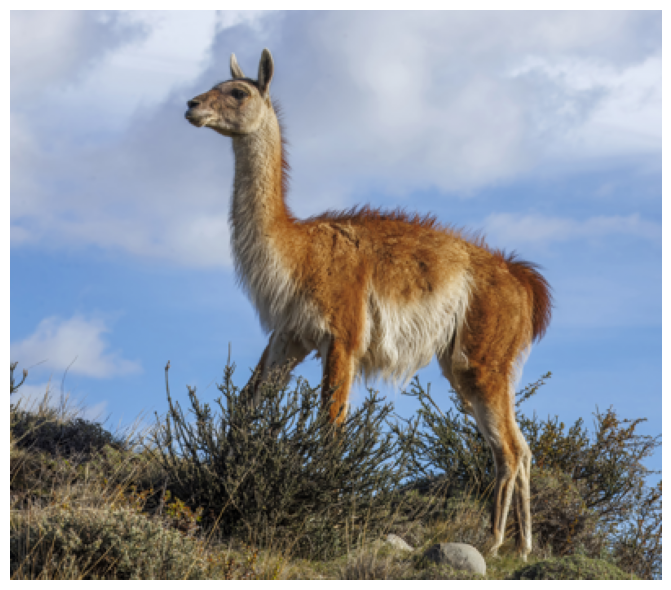

In [15]:
def load_img(route, scale=None, width=None, height=None):
    img = Image.open(route)
    print(f"Original image size: {img.size}")

    if np.sum([scale is not None, width is not None, height is not None]) > 1:
        raise ValueError("Only one of scale, width, or height should be provided.")

    if scale is not None:
        new_size = (int(img.width * scale), int(img.height * scale))
        img = img.resize(new_size)
    
        print(f"Resized image size: {img.size}")

    elif width is not None:
        aspect_ratio = img.height / img.width
        new_size = (width, int(width * aspect_ratio))
        img = img.resize(new_size)
    
        print(f"Resized image size: {img.size}")
    
    elif height is not None:
        aspect_ratio = img.width / img.height
        new_size = (int(height * aspect_ratio), height)
        img = img.resize(new_size)
    
        print(f"Resized image size: {img.size}")

    img_array = np.array(img)[:,:,:3] /255.

    return img_array

def save_png(out, path):
    out_clipped = np.clip(out, 0, 255)
    out_uint8 = out_clipped.astype(np.uint8)

    Image.fromarray(out_uint8, mode="RGB").save(path)

img = load_img('guanaco.jpg', width=400)
plot_image(img)

## Heat equation solving

Se resolverá la ecuación de calor en una matriz, se tomará 0 como frontera.

### Ecuación de calor
La ecuación de calor en dos dimensiones está dada por:
$$
\frac{\partial u}{\partial t} = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

In [22]:
u = img[:,:,0]  # Usar el canal rojo como ejemplo de temperatura inicial

def heat_equation_step(u, alpha, dt):
    u_new = u.copy()

    u_hat = np.fft.fft2(u)
    kx = np.fft.fftfreq(u.shape[1]) * 2 * np.pi
    ky = np.fft.fftfreq(u.shape[0]) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky)
    laplacian_hat = -(KX**2 + KY**2) * u_hat

    # Euler explícito en el espacio de Fourier
    u_new_hat = u_hat + alpha * dt * laplacian_hat

    # Implementación con RK4 en el espacio de Fourier
    # def rhs(u_hat):
    #     return alpha * (-(KX**2 + KY**2) * u_hat)

    # k1 = rhs(u_hat)
    # k2 = rhs(u_hat + 0.5 * dt * k1)
    # k3 = rhs(u_hat + 0.5 * dt * k2)
    # k4 = rhs(u_hat + dt * k3)
    # u_new_hat = u_hat + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    u_new = np.fft.ifft2(u_new_hat).real

    return u_new

In [23]:
# Interactive visualization
@interact(alpha=(0.01, 1.0, 0.01),
            dt=(0.01, 1.0, 0.01), steps=(1, 100, 1))
def update(alpha=0.1, dt=0.1, steps=10):
    u_temp = u.copy()
    for _ in range(steps):
        u_temp = heat_equation_step(u_temp, alpha, dt)
    plot_image(u_temp, cmap='hot')

interactive(children=(FloatSlider(value=0.1, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

In [ ]:
r,g,b = img[:,:,0], img[:,:,1], img[:,:,2]

@interact(alpha=(0.01, 1.0, 0.01),
            dt=(0.01, 1.0, 0.01), steps=(1, 600, 1))
def update(alpha=0.1, dt=0.1, steps=10):
    r_temp = r.copy()
    g_temp = g.copy()
    b_temp = b.copy()
    for _ in range(steps):
        r_temp = heat_equation_step(r_temp, alpha, dt)
        g_temp = heat_equation_step(g_temp, alpha, dt)
        b_temp = heat_equation_step(b_temp, alpha, dt)
    img_solved = np.stack([r_temp, g_temp, b_temp], axis=2)
    img_clipped = np.clip(img_solved, 0, 1)
    plot_image(img_clipped)

interactive(children=(FloatSlider(value=0.1, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

In [27]:
# save frames of the evolution
def save_heat_equation_evolution(img, alpha, dt, steps, path_template):
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    r_temp = r.copy()
    g_temp = g.copy()
    b_temp = b.copy()

    for step in range(steps):
        r_temp = heat_equation_step(r_temp, alpha, dt)
        g_temp = heat_equation_step(g_temp, alpha, dt)
        b_temp = heat_equation_step(b_temp, alpha, dt)

        img_solved = np.stack([r_temp, g_temp, b_temp], axis=2)
        img_clipped = np.clip(img_solved, 0, 1)
        path = path_template.format(step=step)
        save_png(img_clipped * 255, path)

save_heat_equation_evolution(img, alpha=1.0, dt=0.15, steps=600, path_template='frames/frame_{step:03d}.png')